# Телеком — Поиск клиента с неоптимальными тарифами

**Задача:**
Найти клиентов, которые:
а) переплачивают на текущих тарифах;
б) сэкономят, если перейдут на более дорогой тариф.

**Ежемесячная плата за тариф:**
Тариф А — 4000 ₽,
Тариф B — 2000 ₽,
Тариф С — 1000 ₽.

**Дополнительная ежемесячная плата за
каждого оператора:**
Тариф А — 50 ₽,
Тариф B — 150 ₽,
Тариф С — 300 ₽.

**Входящие и внутренние звонки — бесплатны на всех тарифах, Исходящие звонки внутри сети, включённые в тариф:**
Тариф А — 2000
минут,
Тариф B — 500 минут,
Тариф С — нет.

**Цена сверх лимита:**
A — 0.1 ₽/мин.,
B — 0.15 ₽/мин.,
C — 0.3 ₽/мин.

**Исходящие звонки, кроме внутренних:**
A — 0.3 ₽/мин.,
B — 0.5 ₽/мин.,
C — 0.7 ₽/мин.

**Описание данных:**
Датасеты описывают использование услуг «Нупозвони» — провайдера виртуальной телефонии. Его клиенты — колл-центры, которые: распределяют входящие вызовы на операторов, совершают исходящие вызовы силами операторов. Также операторы могут делать внутренние вызовы — вызовы друг между другом
внутри сети виртуальной телефонии.

# Импорт библиотек и настройки

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st
import warnings

# Настройки отображения
pd.set_option('display.float_format', '{:,.2f}'.format)
warnings.filterwarnings('ignore')
pd.options.display.max_columns = 20

# Загрузка и предобработка данных

In [ ]:
# Загрузка данных
try:
    data_clients = pd.read_csv('../data/telecom_clients.csv', sep=',')
    data_dataset = pd.read_csv('../data/telecom_dataset.csv', sep=',')
except FileNotFoundError:
    try:
        data_clients = pd.read_csv('https://code.s3.yandex.net/datasets/telecom_clients.csv')
        data_dataset = pd.read_csv('https://code.s3.yandex.net/datasets/telecom_dataset.csv')
    except Exception as e:
        print(f"Ошибка при загрузке данных: {e}")
        exit()


In [ ]:
data_clients

     user_id tariff_plan  date_start
0     166713           A  2019-08-15
1     166901           A  2019-08-23
2     168527           A  2019-10-29
3     167097           A  2019-09-01
4     168193           A  2019-10-16
..       ...         ...         ...
727   166554           B  2019-08-08
728   166911           B  2019-08-23
729   167012           B  2019-08-28
730   166867           B  2019-08-22
731   166565           B  2019-08-08

[732 rows x 3 columns]

In [ ]:
data_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [ ]:
data_dataset

       user_id                       date direction internal  operator_id  \
0       166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1       166377  2019-08-05 00:00:00+03:00       out     True   880,022.00   
2       166377  2019-08-05 00:00:00+03:00       out     True   880,020.00   
3       166377  2019-08-05 00:00:00+03:00       out     True   880,020.00   
4       166377  2019-08-05 00:00:00+03:00       out    False   880,022.00   
...        ...                        ...       ...      ...          ...   
53897   168606  2019-11-10 00:00:00+03:00       out     True   957,922.00   
53898   168606  2019-11-11 00:00:00+03:00       out     True   957,922.00   
53899   168606  2019-11-15 00:00:00+03:00       out     True   957,922.00   
53900   168606  2019-11-15 00:00:00+03:00       out     True   957,922.00   
53901   168606  2019-11-19 00:00:00+03:00        in    False          NaN   

       is_missed_call  calls_count  call_duration  total_call_duration  
0 

In [ ]:
data_dataset.query('user_id == 168601')['date'].min()

'2019-11-01 00:00:00+03:00'

In [ ]:
data_dataset.query('user_id == 168598')['date'].min()

'2019-11-04 00:00:00+03:00'

In [ ]:
data_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [ ]:
# Преобразование дат
data_clients['date_start'] = pd.to_datetime(data_clients['date_start'])
data_dataset['date'] = pd.to_datetime(data_dataset['date'])
# Удаяем временную зону
data_dataset['date'] = pd.to_datetime(data_dataset['date']).dt.tz_localize(None)

In [ ]:
# Заполнение пропусков
data_dataset['internal'] = data_dataset['internal'].fillna(False)
data_dataset['operator_id'] = data_dataset['operator_id'].fillna(-1).astype(int)

In [ ]:
# Проверка данных перед объединением
print("=== Проверка данных перед объединением ===")
print(f"Уникальных клиентов в clients: {data_clients['user_id'].nunique()}")
print(f"Уникальных клиентов в dataset: {data_dataset['user_id'].nunique()}")
print(f"Клиенты без звонков: {len(set(data_clients['user_id']) - set(data_dataset['user_id']))}")

=== Проверка данных перед объединением ===
Уникальных клиентов в clients: 732
Уникальных клиентов в dataset: 307
Клиенты без звонков: 425


In [ ]:
# Находим дату первого звонка для каждого пользователя
first_calls = data_dataset.groupby('user_id')['date'].min().reset_index()
first_calls

     user_id       date
0     166377 2019-08-04
1     166391 2019-08-06
2     166392 2019-08-02
3     166399 2019-08-12
4     166405 2019-08-03
..       ...        ...
302   168583 2019-10-31
303   168598 2019-11-04
304   168601 2019-11-01
305   168603 2019-11-12
306   168606 2019-11-08

[307 rows x 2 columns]

In [ ]:
# Объединяем с информацией о клиентах (левым), чтобы сохранить всех клиентов
data_test = pd.merge(data_clients, first_calls, on='user_id', how='left')

In [ ]:
# Проверяем, что дата начала тарифа не раньше даты первого звонка
data_test['is_valid'] = data_test['date_start'] <= data_test['date']
data_test

     user_id tariff_plan date_start       date  is_valid
0     166713           A 2019-08-15 2019-08-21      True
1     166901           A 2019-08-23 2019-08-24      True
2     168527           A 2019-10-29        NaT     False
3     167097           A 2019-09-01        NaT     False
4     168193           A 2019-10-16 2019-10-22      True
..       ...         ...        ...        ...       ...
727   166554           B 2019-08-08 2019-08-09      True
728   166911           B 2019-08-23        NaT     False
729   167012           B 2019-08-28 2019-08-28      True
730   166867           B 2019-08-22        NaT     False
731   166565           B 2019-08-08        NaT     False

[732 rows x 5 columns]

In [ ]:
print("\n=== Проверка корректности дат ===")
print(f"Клиенты с некорректными датами: {len(data_test[~data_test['is_valid']])}")
print(data_test[~data_test['is_valid']][['user_id', 'date_start', 'date']].head())


=== Проверка корректности дат ===
Клиенты с некорректными датами: 425
   user_id date_start date
2   168527 2019-10-29  NaT
3   167097 2019-09-01  NaT
5   167764 2019-09-30  NaT
6   167050 2019-08-29  NaT
8   168495 2019-10-28  NaT


In [ ]:
data = pd.merge(data_clients, data_dataset, on='user_id', how='outer')
data

       user_id tariff_plan date_start       date direction internal  \
0       166713           A 2019-08-15 2019-08-21        in    False   
1       166713           A 2019-08-15 2019-08-22        in    False   
2       166713           A 2019-08-15 2019-08-22        in    False   
3       166713           A 2019-08-15 2019-08-22        in    False   
4       166713           A 2019-08-15 2019-08-26        in    False   
...        ...         ...        ...        ...       ...      ...   
54322   167012           B 2019-08-28 2019-08-30        in    False   
54323   167012           B 2019-08-28 2019-08-30       out     True   
54324   167012           B 2019-08-28 2019-08-30       out    False   
54325   166867           B 2019-08-22        NaT       NaN      NaN   
54326   166565           B 2019-08-08        NaT       NaN      NaN   

       operator_id is_missed_call  calls_count  call_duration  \
0            -1.00           True         4.00           0.00   
1       891,918.0

In [ ]:
rows_with_nan = data[data.isna().any(axis=1)]
rows_with_nan

       user_id tariff_plan date_start date direction internal  operator_id  \
498     168527           A 2019-10-29  NaT       NaN      NaN          NaN   
499     167097           A 2019-09-01  NaT       NaN      NaN          NaN   
584     167764           A 2019-09-30  NaT       NaN      NaN          NaN   
585     167050           A 2019-08-29  NaT       NaN      NaN          NaN   
1515    168495           A 2019-10-28  NaT       NaN      NaN          NaN   
...        ...         ...        ...  ...       ...      ...          ...   
54309   166815           B 2019-08-20  NaT       NaN      NaN          NaN   
54310   166702           B 2019-08-15  NaT       NaN      NaN          NaN   
54312   166911           B 2019-08-23  NaT       NaN      NaN          NaN   
54325   166867           B 2019-08-22  NaT       NaN      NaN          NaN   
54326   166565           B 2019-08-08  NaT       NaN      NaN          NaN   

      is_missed_call  calls_count  call_duration  total_call_du

**Вывод:**

1) Мы видим, что после объединения у нас 425 строк с пустыми значениями, связанно с тем, что данные пользователи есть в тарифной базе, но отсутствовали в датасете по звонкам.

2) Их можно удалить

In [ ]:
data.dropna(inplace=True)

In [ ]:
data.query('user_id == 168601')['date'].min()

Timestamp('2019-11-01 00:00:00')

In [ ]:
data.query('user_id == 168598')['date'].min()

Timestamp('2019-11-04 00:00:00')

In [ ]:
print("===Итог===")
print(f"Всего уникальных клиентов: {data['user_id'].nunique()}")
print(f"Клиенты с тарифом, но без звонков: {len(set(data_clients['user_id']) - set(data_dataset['user_id']))}")
print(f"Клиенты со звонками, но без тарифа: {len(set(data_dataset['user_id']) - set(data_clients['user_id']))}")
print("Пользователи с несколькими тарифами:", data.groupby('user_id')['tariff_plan'].nunique().gt(1).sum())

===Итог===
Всего уникальных клиентов: 307
Клиенты с тарифом, но без звонков: 425
Клиенты со звонками, но без тарифа: 0
Пользователи с несколькими тарифами: 0


In [ ]:
# Проверка пользователей у кого дата звонка меньше даты начала
invalid_dates = data[data['date'] < data['date_start']]
if len(invalid_dates) > 0:
    print(f"\nУдалено записей с звонками до регистрации: {len(invalid_dates)}")
    data = data[data['date'] >= data['date_start']]
else:
    print("Записи отсутствуют")

Записи отсутствуют


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53902 entries, 0 to 54324
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              53902 non-null  int64         
 1   tariff_plan          53902 non-null  object        
 2   date_start           53902 non-null  datetime64[ns]
 3   date                 53902 non-null  datetime64[ns]
 4   direction            53902 non-null  object        
 5   internal             53902 non-null  object        
 6   operator_id          53902 non-null  float64       
 7   is_missed_call       53902 non-null  object        
 8   calls_count          53902 non-null  float64       
 9   call_duration        53902 non-null  float64       
 10  total_call_duration  53902 non-null  float64       
dtypes: datetime64[ns](2), float64(4), int64(1), object(4)
memory usage: 4.9+ MB


**Вывод:**

1) После объединения таблиц мы не потеряли строк, пропущенных значений нет, пустых значений также нет.

2) Для каждого пользователя нашелся тариф, нет пользователей с несколькими тарифами.

3) Отсутствуют клиенты у кого дата начала обслуживание выше даты совершения звонка.

4) Получили 307 уникальных клиента.

In [ ]:
# Проверка данных
print("=== Основная информация о данных ===")
print(f"Период данных: с {data['date'].min()} по {data['date'].max()}")
print(f"Уникальных операторов: {data[data['operator_id'] != -1]['operator_id'].nunique()}")
print(f"Общее количество записей: {len(data)}")

=== Основная информация о данных ===
Период данных: с 2019-08-02 00:00:00 по 2019-11-28 00:00:00
Уникальных операторов: 1092
Общее количество записей: 53902


In [ ]:
# Проверяем наличие полных дубликатов
data_dup = data[data.duplicated(keep=False)]
data_dup_list = data_dup.sort_values(by=data.columns.tolist())
data_dup_list

       user_id tariff_plan date_start       date direction internal  \
52405   166377           B 2019-08-01 2019-08-05       out    False   
52407   166377           B 2019-08-01 2019-08-05       out    False   
52426   166377           B 2019-08-01 2019-08-12        in    False   
52427   166377           B 2019-08-01 2019-08-12        in    False   
52437   166377           B 2019-08-01 2019-08-14        in    False   
...        ...         ...        ...        ...       ...      ...   
16797   168601           C 2019-10-31 2019-11-26        in    False   
38171   168603           B 2019-10-31 2019-11-20       out    False   
38173   168603           B 2019-10-31 2019-11-20       out    False   
16460   168606           C 2019-10-31 2019-11-15       out     True   
16461   168606           C 2019-10-31 2019-11-15       out     True   

       operator_id is_missed_call  calls_count  call_duration  \
52405   880,020.00           True         8.00           0.00   
52407   880,020.0

In [ ]:
duplicates_count = data.duplicated().sum()
print(f"Найдено дубликатов: {duplicates_count} ({duplicates_count/len(data):.1%})")

Найдено дубликатов: 4900 (9.1%)


In [ ]:
# Удаление дубликатов
data = data.drop_duplicates().reset_index(drop=True)
print(f"\nПосле удаления дубликатов: {len(data)} записей")
data


После удаления дубликатов: 49002 записей


       user_id tariff_plan date_start       date direction internal  \
0       166713           A 2019-08-15 2019-08-21        in    False   
1       166713           A 2019-08-15 2019-08-22        in    False   
2       166713           A 2019-08-15 2019-08-22        in    False   
3       166713           A 2019-08-15 2019-08-22        in    False   
4       166713           A 2019-08-15 2019-08-26        in    False   
...        ...         ...        ...        ...       ...      ...   
48997   167012           B 2019-08-28 2019-08-30       out    False   
48998   167012           B 2019-08-28 2019-08-30       out     True   
48999   167012           B 2019-08-28 2019-08-30        in    False   
49000   167012           B 2019-08-28 2019-08-30       out     True   
49001   167012           B 2019-08-28 2019-08-30       out    False   

       operator_id is_missed_call  calls_count  call_duration  \
0            -1.00           True         4.00           0.00   
1       891,918.0

In [ ]:
data

       user_id tariff_plan date_start       date direction internal  \
0       166713           A 2019-08-15 2019-08-21        in    False   
1       166713           A 2019-08-15 2019-08-22        in    False   
2       166713           A 2019-08-15 2019-08-22        in    False   
3       166713           A 2019-08-15 2019-08-22        in    False   
4       166713           A 2019-08-15 2019-08-26        in    False   
...        ...         ...        ...        ...       ...      ...   
48997   167012           B 2019-08-28 2019-08-30       out    False   
48998   167012           B 2019-08-28 2019-08-30       out     True   
48999   167012           B 2019-08-28 2019-08-30        in    False   
49000   167012           B 2019-08-28 2019-08-30       out     True   
49001   167012           B 2019-08-28 2019-08-30       out    False   

       operator_id is_missed_call  calls_count  call_duration  \
0            -1.00           True         4.00           0.00   
1       891,918.0

<div style="border:solid lightblue 4px; padding: 20px">

**Вывод:**

    1) Загрузили данные из датасетов, один датасет к тарифным планом пользователей, другой датасет с информацией о звонках пользователей, проверили тип данных и получили информацию о датасете:
    - Период данных: с 2019-08-02 по 2019-11-28
    - Уникальных клиентов: 307
    - Уникальных операторов: 1092
Общее количество записей: 4902

    3) Привели столбцы с датой в датасетатах с типу datetime.

    4) Заполнили пропуски в категориальном и количественном столбце. Данные в стобце с маркером внутренних и внешних вызовов заполнили значением "Неизвестен", в столбце с id оператора заполнили отрицательным значением, в последующем анализе будем фильтровать.

    5) Объединили датасеты по id пользователя методом outer.

    6) Из новой таблицы удалили строки с явными дубликатами, было найдено 4900 строк дубликатов - 9.1% от общего числа, удалено 3950.

    7) Удалили временную зону, так как она не несет в себе никакой информации


# Исследовательский анализ

## Определение активных клиентов

### Анализ загруженности колл-центров

In [ ]:
# Фильтрация операторских данных
operators_data = data[data['operator_id'] != -1].copy()
operators_data

       user_id tariff_plan date_start       date direction internal  \
1       166713           A 2019-08-15 2019-08-22        in    False   
2       166713           A 2019-08-15 2019-08-22        in    False   
4       166713           A 2019-08-15 2019-08-26        in    False   
6       166713           A 2019-08-15 2019-09-04        in    False   
7       166713           A 2019-08-15 2019-09-04        in    False   
...        ...         ...        ...        ...       ...      ...   
48995   167012           B 2019-08-28 2019-08-29       out    False   
48997   167012           B 2019-08-28 2019-08-30       out    False   
48998   167012           B 2019-08-28 2019-08-30       out     True   
49000   167012           B 2019-08-28 2019-08-30       out     True   
49001   167012           B 2019-08-28 2019-08-30       out    False   

       operator_id is_missed_call  calls_count  call_duration  \
1       891,918.00          False         1.00          40.00   
2       891,908.0

In [ ]:
operators_data.query('user_id == 168601')['date'].min()

Timestamp('2019-11-02 00:00:00')

<div style="border:solid lightblue 4px; padding: 20px">

**Вывод:**

1) Поставив загрушку на неуказанных операторов мы сократили данные с 51220 до 43839 строк.

2) Заменять пустые значения не стоит, так как придется "угадывать" id оператора.

In [ ]:
# Анализ выбросов
daily_load = operators_data.groupby(['operator_id', pd.Grouper(key='date', freq='D')])['call_duration'].sum().reset_index()
unique_operators = daily_load['operator_id'].nunique()
unique_operators

1092

In [ ]:
# Статистический анализ
print("Статистика нагрузки операторов (минут/день):")
stats = daily_load['call_duration'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
stats

Статистика нагрузки операторов (минут/день):


count    19,647.00
mean      2,135.28
std       5,902.10
min           0.00
25%         144.00
50%         700.00
75%       2,234.00
90%       4,963.40
95%       7,584.80
99%      17,084.12
max     145,006.00
Name: call_duration, dtype: float64

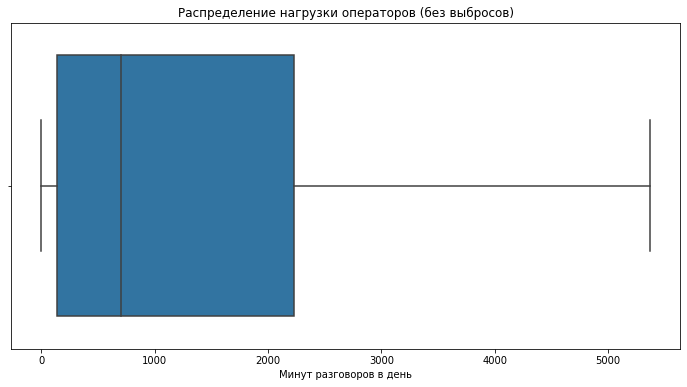

In [ ]:
# Визуализация распределения
plt.figure(figsize=(12, 6))
sns.boxplot(x=daily_load['call_duration'], showfliers=False)
plt.title('Распределение нагрузки операторов (без выбросов)')
plt.xlabel('Минут разговоров в день')
plt.show()

<div style="border:solid lightblue 4px; padding: 20px">

**Вывод:**
1) Если отбросить выбросы, то мы видим, что график скошен немного вправо, это говорит о том, что большинство данных сосредоточено ниже 700, но "хвост" тянется далеко вправо, верхний ус примерно 5500, выше начинаются выбросы.

2) Большинство звонков длятся от 700 минут до 2234 минуты в день это говорит о том, что операторов работает несколько сотрудников, которые совершают звонки.

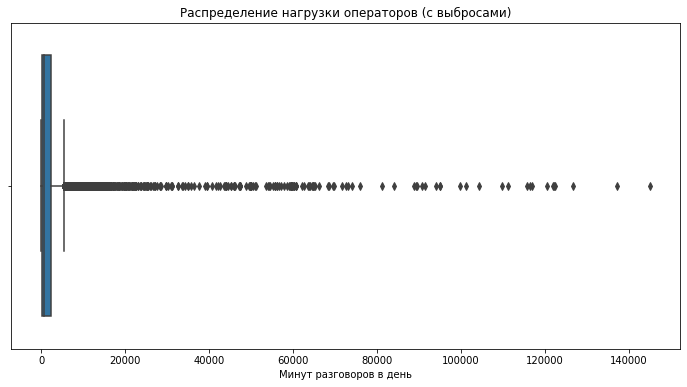

In [ ]:
# Визуализация распределения
plt.figure(figsize=(12, 6))
sns.boxplot(x=daily_load['call_duration'])
plt.title('Распределение нагрузки операторов (с выбросами)')
plt.xlabel('Минут разговоров в день')
plt.show()

**Вывод:**

1) Нужно подробнее изучить выбросы, график скосился вправо слишком сильно.

In [ ]:
# Анализ аномалий без удаления
max_reasonable = 24 * 60  # 1440 минут (24 часа)
anomalies = daily_load[daily_load['call_duration'] > max_reasonable]

In [ ]:
anomalies_stats = (
    anomalies
    .groupby('operator_id')
    .agg(
        total_duration=('call_duration', 'sum'),
        anomaly_count=('call_duration', 'count')
    )
    .query("anomaly_count >= 4") 
    .sort_values('total_duration', ascending=False)
    .reset_index()
)
anomalies_stats.head(10)

   operator_id  total_duration  anomaly_count
0   885,876.00    4,359,978.00             88
1   885,890.00    3,340,790.00             79
2   925,922.00      826,991.00             22
3   952,948.00      470,081.00             23
4   901,880.00      426,779.00             82
5   913,938.00      366,277.00             55
6   882,686.00      359,085.00             66
7   890,406.00      353,981.00             71
8   890,404.00      342,910.00             71
9   890,402.00      331,910.00             71

In [ ]:
print(f"\nНайдено аномальных записей: {len(anomalies)}")
print("Примеры аномальных записей:")
print(anomalies.sort_values('call_duration', ascending=False).head(30))


Найдено аномальных записей: 6899
Примеры аномальных записей:
     operator_id       date  call_duration
847   885,876.00 2019-09-25     145,006.00
848   885,876.00 2019-09-26     137,138.00
834   885,876.00 2019-09-12     126,716.00
831   885,876.00 2019-09-09     122,521.00
854   885,876.00 2019-10-02     122,108.00
840   885,876.00 2019-09-18     121,836.00
861   885,876.00 2019-10-09     120,476.00
842   885,876.00 2019-09-20     116,836.00
849   885,876.00 2019-09-27     116,527.00
833   885,876.00 2019-09-11     115,702.00
827   885,876.00 2019-09-05     111,307.00
841   885,876.00 2019-09-19     109,852.00
845   885,876.00 2019-09-23     104,202.00
839   885,876.00 2019-09-17     101,163.00
835   885,876.00 2019-09-13      99,893.00
855   885,876.00 2019-10-03      95,104.00
852   885,876.00 2019-09-30      94,947.00
826   885,876.00 2019-09-04      94,055.00
824   885,876.00 2019-09-02      91,447.00
862   885,876.00 2019-10-10      90,779.00
828   885,876.00 2019-09-06      89

In [ ]:
operators_count = (
    operators_data
    .groupby('operator_id')
    .agg(
        user_count=('user_id', 'count'), 
        call_count=('calls_count', 'sum'),  
        total_duration=('total_call_duration', 'sum')
    )
    .sort_values('call_count', ascending=False)
    .reset_index()
)
operators_count

      operator_id  user_count  call_count  total_duration
0      885,890.00         253   60,221.00    4,783,792.00
1      885,876.00         283   59,429.00    5,733,237.00
2      929,428.00          65   23,754.00      633,196.00
3      925,922.00          73   20,021.00    1,252,549.00
4      908,640.00          43   14,239.00      410,932.00
...           ...         ...         ...             ...
1087   946,020.00           1        1.00            8.00
1088   946,032.00           1        1.00          103.00
1089   946,468.00           1        1.00           43.00
1090   947,306.00           1        1.00           31.00
1091   945,274.00           1        1.00           15.00

[1092 rows x 4 columns]

In [ ]:
# Расчет средней нагрузки с учетом выбросов
median_load = stats['50%']
p95_load = stats['99%']

print(f"\nМедианная нагрузка на оператора: {median_load:.1f} мин/день")
print(f"95-й перцентиль нагрузки: {p95_load:.1f} мин/день")


Медианная нагрузка на оператора: 700.0 мин/день
95-й перцентиль нагрузки: 17084.1 мин/день


<div style="border:solid lightblue 4px; padding: 20px">

**Вывод:**

1) Из полученного графика и среза мы видим, что:
    
    - id оператора 885890 и 885876- являются самыми крупным среди всех, ежедневное количество минут превышают показатели всех остальных
    - Медианная нагрузка на оператора: 700.0 мин/день
    
2) Не стоит избавляться от данных, я считаю что есть колл центры в которых работают сотни операторов.

### Добавление столбца с классификацией звонка

1) Если звонок входящий (in), то он по определению не может быть внутренним (так как идет от внешнего абонента)

2) Если звонок исходящий (out):
    - True - внутренний звонок (бесплатный)
    - False - внешний звонок (платный)

In [ ]:
# Классификация звонков
data['call_category'] = np.select(
    [
        data['direction'] == 'in',
        (data['direction'] == 'out') & data['internal'],
        (data['direction'] == 'out') & ~data['internal']
    ],
    [
        'free_inbound',
        'outbound_internal',
        'outbound_external'
    ]
)
data

       user_id tariff_plan date_start       date direction internal  \
0       166713           A 2019-08-15 2019-08-21        in    False   
1       166713           A 2019-08-15 2019-08-22        in    False   
2       166713           A 2019-08-15 2019-08-22        in    False   
3       166713           A 2019-08-15 2019-08-22        in    False   
4       166713           A 2019-08-15 2019-08-26        in    False   
...        ...         ...        ...        ...       ...      ...   
48997   167012           B 2019-08-28 2019-08-30       out    False   
48998   167012           B 2019-08-28 2019-08-30       out     True   
48999   167012           B 2019-08-28 2019-08-30        in    False   
49000   167012           B 2019-08-28 2019-08-30       out     True   
49001   167012           B 2019-08-28 2019-08-30       out    False   

       operator_id is_missed_call  calls_count  call_duration  \
0            -1.00           True         4.00           0.00   
1       891,918.0

In [ ]:
data.query('user_id == 168601')['date'].min()

Timestamp('2019-11-01 00:00:00')

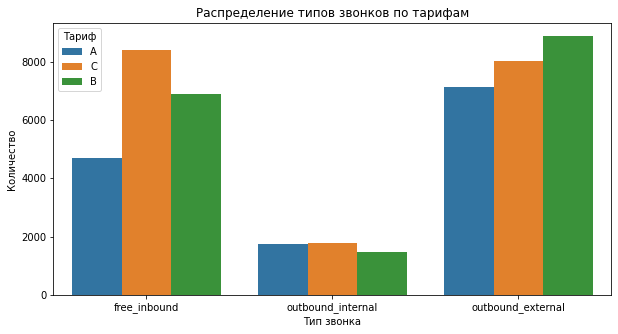

In [ ]:
# Визуализация распределения звонков
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='call_category', hue='tariff_plan')
plt.title('Распределение типов звонков по тарифам')
plt.xlabel('Тип звонка')
plt.ylabel('Количество')
plt.legend(title='Тариф')
plt.show()

In [ ]:
count_viz = (
    data
    .groupby(['call_category', 'tariff_plan'], as_index=False).size().fillna(0)
)
count_viz

       call_category tariff_plan  size
0       free_inbound           A  4705
1       free_inbound           B  6900
2       free_inbound           C  8398
3  outbound_external           A  7118
4  outbound_external           B  8880
5  outbound_external           C  8019
6  outbound_internal           A  1733
7  outbound_internal           B  1457
8  outbound_internal           C  1792

<div style="border:solid lightblue 4px; padding: 20px">

**Вывод:**

1) Бесплатные входящие (free_inbound) — лидер по количеству звонков во всех тарифах (4705, 6900, 8398).

    - Максимум в тарифе C (8398), минимум в A (4705).

    - Возможная причина: тариф C может включать больше бесплатных минут или быть популярен у клиентов, получающих много входящих звонков.

2) Внешние исходящие (outbound_external) — второй по популярности тип.

    - Пик в тарифе B (8880), что может указывать на выгодные условия для внешних вызовов в этом тарифе.

3) Внутренние исходящие (outbound_internal) — наименее популярные (все значения ниже 2000).

    - Разница между тарифами незначительна, что говорит о редком использовании внутренних звонков.

In [ ]:
call_stats = data.groupby(['tariff_plan', 'call_category']).agg(
    total_calls=('user_id', 'count'),
    total_duration=('call_duration', 'sum')
).reset_index()

call_stats['avg_duration'] = call_stats['total_duration'] / call_stats['total_calls']

call_stats['avg_duration'] = call_stats['avg_duration'].round(2)

print("Статистика по звонкам:")
call_stats

Статистика по звонкам:


  tariff_plan      call_category  total_calls  total_duration  avg_duration
0           A       free_inbound         4705    3,269,142.00        694.82
1           A  outbound_external         7118   18,308,420.00      2,572.13
2           A  outbound_internal         1733      250,898.00        144.78
3           B       free_inbound         6900    3,324,075.00        481.75
4           B  outbound_external         8880    6,878,762.00        774.64
5           B  outbound_internal         1457      172,348.00        118.29
6           C       free_inbound         8398    3,252,640.00        387.31
7           C  outbound_external         8019    6,883,943.00        858.45
8           C  outbound_internal         1792      109,327.00         61.01

<div style="border:solid lightblue 4px; padding: 20px">

1) Тариф A — для "тяжелых" звонков:

    - Рекордная длительность исходящих (18.3 млн мин).

    - Долгие входящие (695 мин/звонок).

    - Гипотеза: подходит для корпоративных клиентов или поддержки.

2) Тариф B — для активных, но коротких вызовов:

    - Максимум исходящих звонков (8,880), но в 3 раза короче, чем в A.

    - Гипотеза: подходит для продаж или частых, но быстрых звонков.

3) Тариф C — для массовых входящих:

    - Лидер по входящим (8,398), но минимальная средняя длительность.

    - Гипотеза: подходит для колл-центров с потоковыми запросами (например, справки).

### Создание датафрейма по активным пользователям

In [ ]:
# Определение периода анализа
analysis_start = data['date'].min()
analysis_end = data['date'].max()
print(f"Период анализа: с {analysis_start} по {analysis_end}")

Период анализа: с 2019-08-02 00:00:00 по 2019-11-28 00:00:00


In [ ]:
# Определение периода анализа с более точной детализацией
print("=== Анализ распределения данных по времени ===")
monthly_calls = data['date'].dt.to_period('M').value_counts().sort_index()
print("Количество звонков по месяцам:")
print(monthly_calls)

=== Анализ распределения данных по времени ===
Количество звонков по месяцам:
2019-08     1860
2019-09     8401
2019-10    17193
2019-11    21548
Freq: M, Name: date, dtype: int64


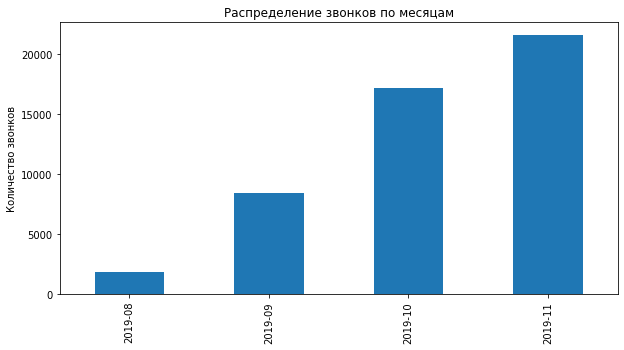

In [ ]:
# Визуализация
plt.figure(figsize=(10, 5))
monthly_calls.plot(kind='bar')
plt.title('Распределение звонков по месяцам')
plt.ylabel('Количество звонков')
plt.show()

**Вывод:**

1) На графике видим, что количество звонков ежемесячно увеличивалось

2) Самый большой показатель, соответсвенно в последний месяц, хотя он не полный

In [ ]:
active_users = data.groupby('user_id').agg(
    first_call=('date', 'min'),
    last_call=('date', 'max'),
    active_months=('date', lambda x: x.dt.to_period('M').nunique())
).merge(
    data_clients[['user_id', 'tariff_plan', 'date_start']],
    on='user_id',
    how='left'
)
active_users

     user_id first_call  last_call  active_months tariff_plan date_start
0     166377 2019-08-04 2019-11-28              4           B 2019-08-01
1     166391 2019-08-06 2019-11-22              4           C 2019-08-01
2     166392 2019-08-02 2019-11-28              4           C 2019-08-01
3     166399 2019-08-12 2019-10-23              3           C 2019-08-01
4     166405 2019-08-03 2019-11-28              4           B 2019-08-02
..       ...        ...        ...            ...         ...        ...
302   168583 2019-10-31 2019-11-28              2           B 2019-10-31
303   168598 2019-11-04 2019-11-28              1           C 2019-10-31
304   168601 2019-11-01 2019-11-28              1           C 2019-10-31
305   168603 2019-11-12 2019-11-28              1           B 2019-10-31
306   168606 2019-11-08 2019-11-19              1           C 2019-10-31

[307 rows x 6 columns]

In [ ]:
# Определяем основной период анализа
analysis_start = pd.Timestamp('2019-09-01')
analysis_end = pd.Timestamp('2019-11-30')

In [ ]:
active_users['is_active'] = (
    (active_users['last_call'] >= analysis_start) & 
    (active_users['active_months'] >= 2)        
)
active_users

     user_id first_call  last_call  active_months tariff_plan date_start  \
0     166377 2019-08-04 2019-11-28              4           B 2019-08-01   
1     166391 2019-08-06 2019-11-22              4           C 2019-08-01   
2     166392 2019-08-02 2019-11-28              4           C 2019-08-01   
3     166399 2019-08-12 2019-10-23              3           C 2019-08-01   
4     166405 2019-08-03 2019-11-28              4           B 2019-08-02   
..       ...        ...        ...            ...         ...        ...   
302   168583 2019-10-31 2019-11-28              2           B 2019-10-31   
303   168598 2019-11-04 2019-11-28              1           C 2019-10-31   
304   168601 2019-11-01 2019-11-28              1           C 2019-10-31   
305   168603 2019-11-12 2019-11-28              1           B 2019-10-31   
306   168606 2019-11-08 2019-11-19              1           C 2019-10-31   

     is_active  
0         True  
1         True  
2         True  
3         True  
4 

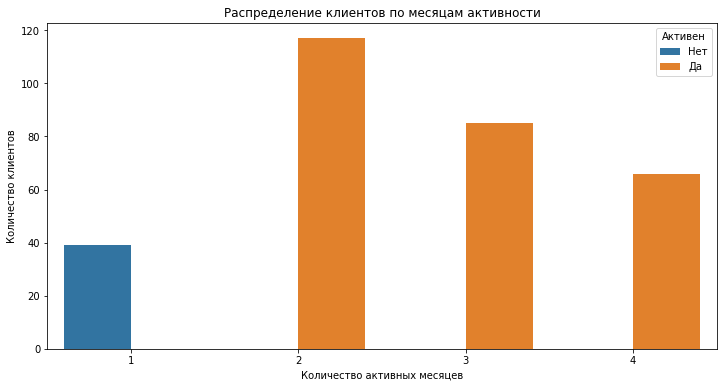

In [ ]:
# Визуализация
plt.figure(figsize=(12, 6))
sns.countplot(data=active_users, x='active_months', hue='is_active')
plt.title('Распределение клиентов по месяцам активности')
plt.xlabel('Количество активных месяцев')
plt.ylabel('Количество клиентов')
plt.legend(title='Активен', labels=['Нет', 'Да'])
plt.show()

In [ ]:
month_stats = (
    active_users
    .groupby(['active_months', 'is_active'], as_index=False)
    .size()
    )
month_stats

   active_months  is_active  size
0              1      False    39
1              2       True   117
2              3       True    85
3              4       True    66

**Вывод:**

1) На графике мы видим, что количество клиентов, не попавших в условие более 2ух месяце активности = 39

2) Отбросим этих клиентов

In [ ]:
print("\nСтатистика активности клиентов:")
active_stats = active_users.groupby('is_active').agg(
    n_clients=('user_id', 'count'),
    avg_active_months=('active_months', 'mean'),
)
print(active_stats)


Статистика активности клиентов:
           n_clients  avg_active_months
is_active                              
False             39               1.00
True             268               2.81


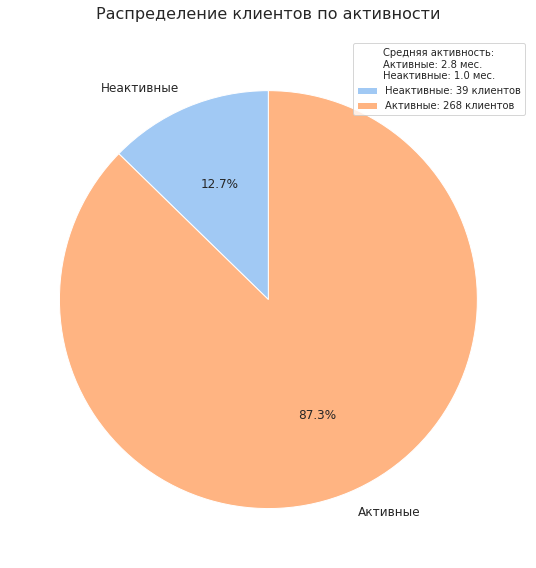

In [ ]:
# Данные
labels = ['Неактивные', 'Активные']
sizes = active_stats['n_clients']
colors = sns.color_palette('pastel')[0:2]  # Пастельные цвета из seaborn

# Настройка стиля seaborn
sns.set_style("whitegrid")

# Создание круговой диаграммы
plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',  # Проценты на секторах
    startangle=90,      # Начальный угол
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},  # Границы секторов
    textprops={'fontsize': 12}
)

# Заголовок
plt.title("Распределение клиентов по активности", fontsize=16, pad=20)

# Легенда с дополнительной информацией
plt.legend(
    [f"{label}: {size} клиентов" for label, size in zip(labels, sizes)],
    title=f"Средняя активность:\nАктивные: {active_stats.loc[True, 'avg_active_months']:.1f} мес.\nНеактивные: {active_stats.loc[False, 'avg_active_months']:.1f} мес.",
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [ ]:
# Финальный отбор активных пользователей
final_active_users = active_users[active_users['is_active']]['user_id']
data_active = data[data['user_id'].isin(final_active_users)].copy()

print(f"\n=== Итоговые показатели ===")
print(f"Всего уникальных клиентов: {data['user_id'].nunique()}")
print(f"Активных клиентов (по новым критериям): {len(final_active_users)}")
print(f"Процент активных клиентов: {len(final_active_users)/data['user_id'].nunique():.1%}")
print("\nРаспределение тарифов у активных клиентов:")
print(data_active.groupby('tariff_plan')['user_id'].nunique())


=== Итоговые показатели ===
Всего уникальных клиентов: 307
Активных клиентов (по новым критериям): 268
Процент активных клиентов: 87.3%

Распределение тарифов у активных клиентов:
tariff_plan
A     32
B     89
C    147
Name: user_id, dtype: int64


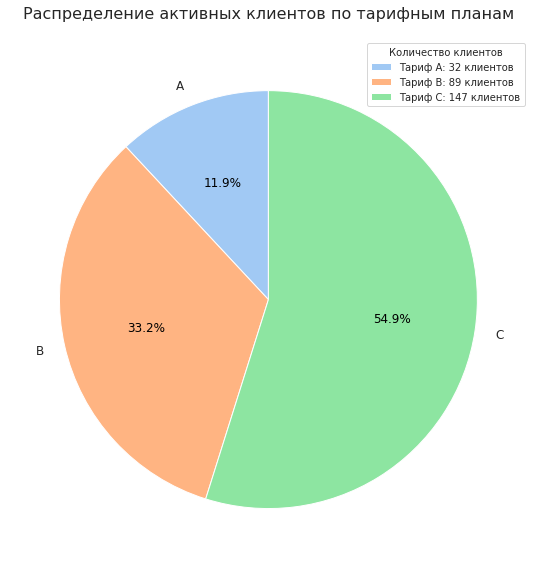

In [ ]:
# Данные
tariff_data = {
    'A': 32,
    'B': 89,
    'C': 147
}

# Настройка стиля seaborn
sns.set_style("whitegrid")

# Цветовая палитра
colors = sns.color_palette('pastel')[0:3]

# Создание круговой диаграммы
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    tariff_data.values(),
    labels=tariff_data.keys(),
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    textprops={'fontsize': 12}
)

# Увеличиваем размер процентных подписей
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('black')

# Заголовок
plt.title("Распределение активных клиентов по тарифным планам", fontsize=16, pad=20)

# Легенда с количеством клиентов
legend_labels = [f"Тариф {tariff}: {count} клиентов" for tariff, count in tariff_data.items()]
plt.legend(legend_labels, title="Количество клиентов", loc="upper right")

plt.tight_layout()
plt.show()

<div style="border:solid lightblue 4px; padding: 20px">


1) Из 307 уникальных клиентов 268 (87.3%) соответствуют критерию активности (более 2 месяцев использования услуг)

2) Средний период активности составляет 2.81 месяца, что свидетельствует о хорошем уровне удержания клиентов

3) Наиболее популярен тариф C (147 клиентов) - 55% от активной базы

4) Тариф B занимает второе место (89 клиентов - 33%)

5) Тариф A наименее востребован (32 клиента - всего 12%)

6) Наблюдается устойчивый рост количества звонков:

    - Август 2019: 1,860 звонков

    - Сентябрь: 8,401

    - Октябрь: 17,193

    - Ноябрь: 21,548 (+25%, при неполном месяце)

7) Пик активности приходится на последний месяц исследования (ноябрь 2019)

8) 39 клиентов (12.7% от общей базы) использовали услуги менее 2 месяцев

## Расчет стоимости тарифов

In [ ]:
# Создаем функцию для расчета стоимости по каждому тарифу
def calculate_tariff_cost(row, tariff):
    """
    Расчет стоимости для конкретного тарифа
    Параметры:
    - row: строка DataFrame с данными клиента
    - tariff: 'A', 'B' или 'C'
    """
    params = {
        'A': {'base': 4000, 'op_fee': 50, 'internal_limit': 2000, 'internal_rate': 0.1, 'external_rate': 0.3},
        'B': {'base': 2000, 'op_fee': 150, 'internal_limit': 500, 'internal_rate': 0.15, 'external_rate': 0.5},
        'C': {'base': 1000, 'op_fee': 300, 'internal_limit': 0, 'internal_rate': 0.3, 'external_rate': 0.7}
    }[tariff]
    
    # Расчет стоимости внутренних звонков
    internal_cost = max(row['internal_mins'] - params['internal_limit'], 0) * params['internal_rate']
    
    # Расчет стоимости внешних звонков
    external_cost = row['external_mins'] * params['external_rate']
    
    # Общая стоимость
    total_cost = (
        params['base'] + 
        params['op_fee'] * row['operator_count'] + 
        internal_cost + 
        external_cost
    )
    
    return total_cost

In [ ]:
# Агрегируем данные по месяцам для каждого клиента
monthly_stats = data_active.groupby(['user_id', 'tariff_plan', pd.Grouper(key='date', freq='M')]).agg(
    operator_count=('operator_id', lambda x: x[x != -1].nunique()),
    internal_mins=('call_duration', lambda x: x[(data_active.loc[x.index, 'call_category'] == 'outbound_internal')].sum()),
    external_mins=('call_duration', lambda x: x[(data_active.loc[x.index, 'call_category'] == 'outbound_external')].sum())
).reset_index()

In [ ]:
# Рассчитываем стоимость для каждого тарифа помесячно
for tariff in ['A', 'B', 'C']:
    monthly_stats[f'{tariff}_cost'] = monthly_stats.apply(
        lambda x: calculate_tariff_cost(x, tariff), 
        axis=1
    )

In [ ]:
# Добавляем текущую стоимость
monthly_stats['current_cost'] = monthly_stats.apply(
    lambda x: calculate_tariff_cost(x, x['tariff_plan']), 
    axis=1
)

In [ ]:
# Агрегируем по клиентам (суммируем помесячные данные)
client_stats = monthly_stats.groupby(['user_id', 'tariff_plan']).agg(
    operator_count=('operator_count', 'mean'),
    internal_mins=('internal_mins', 'sum'),
    external_mins=('external_mins', 'sum'),
    current_cost=('current_cost', 'sum'),
    A_cost=('A_cost', 'sum'),
    B_cost=('B_cost', 'sum'),
    C_cost=('C_cost', 'sum')
).reset_index()
client_stats

     user_id tariff_plan  operator_count  internal_mins  external_mins  \
0     166377           B            4.50         132.00     310,419.00   
1     166391           C            1.00           0.00           0.00   
2     166392           C            2.00           0.00           0.00   
3     166399           C            1.00           0.00           0.00   
4     166405           B            6.00         306.00     770,393.00   
..       ...         ...             ...            ...            ...   
263   168473           C            0.50           0.00         237.00   
264   168500           B            0.50           6.00           0.00   
265   168522           C            1.00           0.00           0.00   
266   168575           C            1.00           0.00           0.00   
267   168583           B            1.50           0.00           0.00   

     current_cost     A_cost     B_cost     C_cost  
0      165,909.50 110,025.70 165,909.50 226,732.90  
1    

In [ ]:
tariff = client_stats.groupby('tariff_plan').agg(
    clients=('user_id', 'count'))
tariff

             clients
tariff_plan         
A                 32
B                 89
C                147

In [ ]:
# Определяем оптимальный тариф и потенциальную экономию
client_stats['optimal_tariff'] = client_stats[['A_cost', 'B_cost', 'C_cost']].idxmin(axis=1).str.replace('_cost', '')
client_stats['potential_savings'] = client_stats['current_cost'] - client_stats[['A_cost', 'B_cost', 'C_cost']].min(axis=1)
client_stats

     user_id tariff_plan  operator_count  internal_mins  external_mins  \
0     166377           B            4.50         132.00     310,419.00   
1     166391           C            1.00           0.00           0.00   
2     166392           C            2.00           0.00           0.00   
3     166399           C            1.00           0.00           0.00   
4     166405           B            6.00         306.00     770,393.00   
..       ...         ...             ...            ...            ...   
263   168473           C            0.50           0.00         237.00   
264   168500           B            0.50           6.00           0.00   
265   168522           C            1.00           0.00           0.00   
266   168575           C            1.00           0.00           0.00   
267   168583           B            1.50           0.00           0.00   

     current_cost     A_cost     B_cost     C_cost optimal_tariff  \
0      165,909.50 110,025.70 165,909.50 22

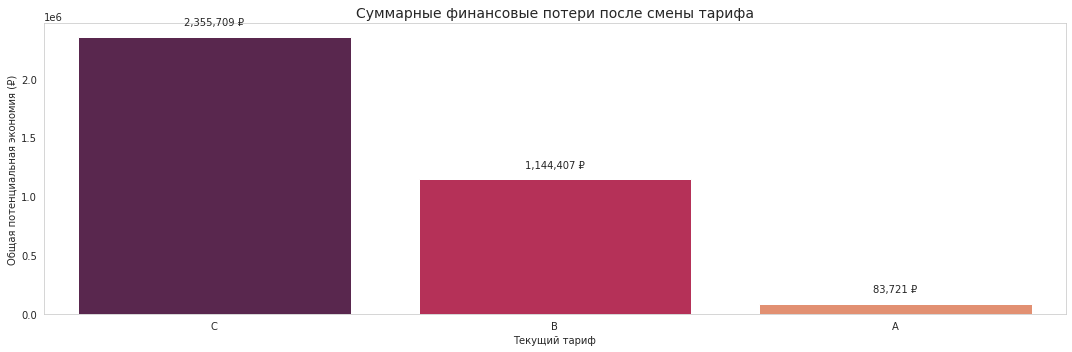

In [ ]:
loss_by_tariff = client_stats.groupby('tariff_plan')['potential_savings'].sum().sort_values(ascending=False)

plt.figure(figsize=(15, 5))
sns.barplot(
    x=loss_by_tariff.index,
    y=loss_by_tariff.values,
    palette='rocket'
)

plt.title('Суммарные финансовые потери после смены тарифа', fontsize=14)
plt.xlabel('Текущий тариф')
plt.ylabel('Общая потенциальная экономия (₽)')

# Добавляем подписи значений
for i, value in enumerate(loss_by_tariff.values):
    plt.text(
        i, 
        value + 100000, 
        f"{value:,.0f} ₽", 
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

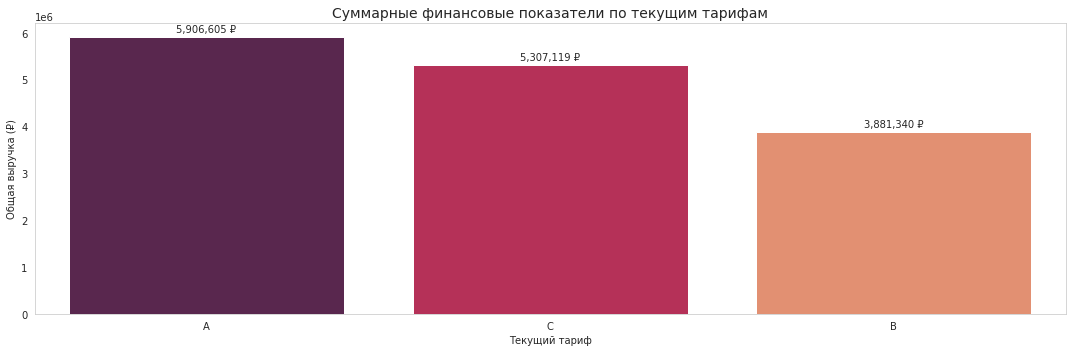

In [ ]:
current_tariff = client_stats.groupby('tariff_plan')['current_cost'].sum().sort_values(ascending=False)

plt.figure(figsize=(15, 5))
sns.barplot(
    x=current_tariff.index,
    y=current_tariff.values,
    palette='rocket'
)

plt.title('Суммарные финансовые показатели по текущим тарифам', fontsize=14)
plt.xlabel('Текущий тариф')
plt.ylabel('Общая выручка (₽)')

# Добавляем подписи значений
for i, value in enumerate(current_tariff.values):
    plt.text(
        i, 
        value + 100000, 
        f"{value:,.0f} ₽", 
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# 7. Анализ результатов
print("\n=== Анализ стоимости тарифов ===")
print(f"Проанализировано клиентов: {len(client_stats)}")
print(f"Средняя текущая стоимость: {client_stats['current_cost'].mean():.2f} ₽")
print(f"Средняя потенциальная экономия: {client_stats['potential_savings'].mean():.2f} ₽")


=== Анализ стоимости тарифов ===
Проанализировано клиентов: 268
Средняя текущая стоимость: 56324.87 ₽
Средняя потенциальная экономия: 13372.53 ₽


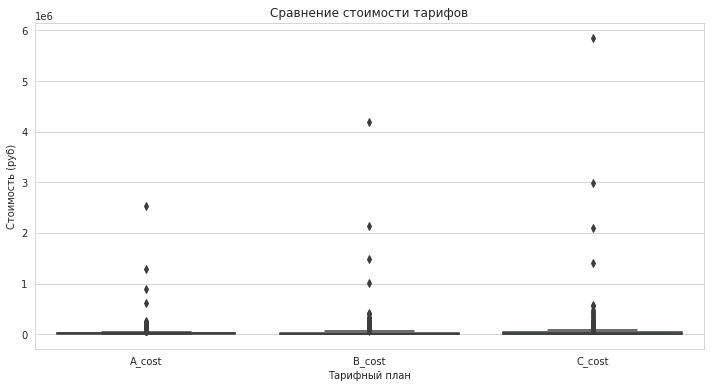

In [ ]:
# Визуализация распределения стоимости
plt.figure(figsize=(12, 6))
sns.boxplot(data=client_stats.melt(id_vars=['user_id'], 
            value_vars=['A_cost', 'B_cost', 'C_cost'], 
            var_name='Тариф', 
            value_name='Стоимость'),
        x='Тариф',
        y='Стоимость')
plt.title('Сравнение стоимости тарифов')
plt.ylabel('Стоимость (руб)')
plt.xlabel('Тарифный план')
plt.show()


<div style="border:solid lightblue 4px; padding: 20px">

**Вывод:**
1) Проанализировано клиентов: 268 клиента

2) Средняя текущая стоимость: 56324.87 ₽ ₽

3) Средняя потенциальная экономия: 13372.53 ₽

4) Самая высокая стоимость у абонентов тафира А, затем В и С, но показатели выбросов у С больше, так как нет лимита по минутам.

## Результаты проведенного анализа

In [ ]:
suboptimal = client_stats[client_stats['tariff_plan'] != client_stats['optimal_tariff']]
current_revenue = client_stats['current_cost'].sum()
optimal_revenue = client_stats[['A_cost', 'B_cost', 'C_cost']].min(axis=1).sum()

print("\n=== Результаты анализа ===")
print(f"Активных клиентов: {len(client_stats)}")
print(f"Клиентов с неоптимальным тарифом: {len(suboptimal)} ({len(suboptimal)/len(client_stats):.1%})")
print(f"Текущая выручка: {current_revenue:,.0f} ₽")
print(f"Потенциальная выручка: {optimal_revenue:,.0f} ₽")
print(f"Возможные потери выручки: {current_revenue - optimal_revenue:,.0f} ₽ ({(current_revenue - optimal_revenue)/current_revenue:.1%})")


=== Результаты анализа ===
Активных клиентов: 268
Клиентов с неоптимальным тарифом: 143 (53.4%)
Текущая выручка: 15,095,064 ₽
Потенциальная выручка: 11,511,227 ₽
Возможные потери выручки: 3,583,837 ₽ (23.7%)


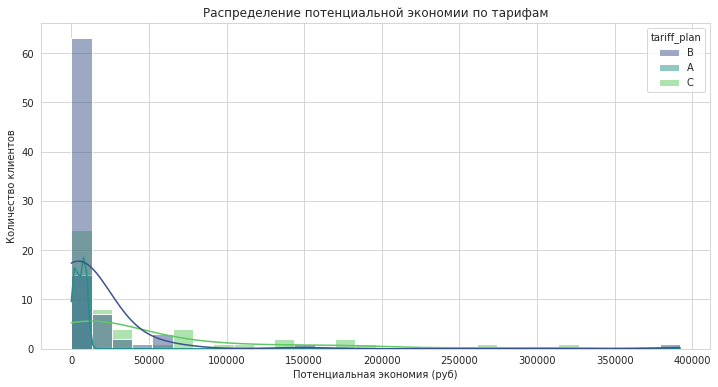

In [ ]:
# Распределение потенциальной экономии
plt.figure(figsize=(12, 6))
sns.histplot(data=suboptimal, x='potential_savings', 
             hue='tariff_plan', bins=30, kde=True,
             palette='viridis')
plt.title('Распределение потенциальной экономии по тарифам')
plt.xlabel('Потенциальная экономия (руб)')
plt.ylabel('Количество клиентов')
plt.show()

In [ ]:
# Сводная статистика по тарифам
saving_data = suboptimal.groupby('tariff_plan')['potential_savings'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
).round(2)

print("\nСводная статистика потенциальной экономии:")
saving_data


Сводная статистика потенциальной экономии:


             count      mean    median    min        max       std
tariff_plan                                                       
A               15  5,581.40  5,686.80 576.30   9,868.90  3,315.31
B               78 14,671.89  2,485.50  94.60 392,003.40 47,961.40
C               50 47,114.18 13,569.35  33.40 322,284.00 71,939.25

<div style="border:solid lightblue 4px; padding: 20px">

**Вывод:**

    1) На графике мы видим, что клиенты тарифного плана В явно превосходят в количестве по неоптимальным тарифам и переплачивают.

    2) Но стоит отметить, что группа клиентов тарифного плана В находится в диапазоне от 0 до 50000 рублей, имеется выброс с показателем почти 400000.

    3) Клиенты группы А визуально слишком сильно переплачивают, наблюдаются в диапазоне от 0 до ~325000 рублей

    4) Клиенты тарифа С самая маленькая группа, переплата от 0 до ~1250.
    
    5) Текущая выручка: 15,095,064 ₽

    6) Потенциальная выручка: 11,511,227 ₽

    7) Возможные потери выручки: 3,583,837 ₽ (23.7%)

## Анализ по тарифам

In [ ]:
tariff_analysis = suboptimal.groupby('tariff_plan').agg(
    clients=('user_id', 'count'),
    avg_savings=('potential_savings', 'mean'),
    total_savings=('potential_savings', 'sum')
).sort_values('total_savings', ascending=False)

print("\nАнализ по тарифам:")
tariff_analysis


Анализ по тарифам:


             clients  avg_savings  total_savings
tariff_plan                                     
C                 50    47,114.18   2,355,709.10
B                 78    14,671.89   1,144,407.10
A                 15     5,581.40      83,721.05

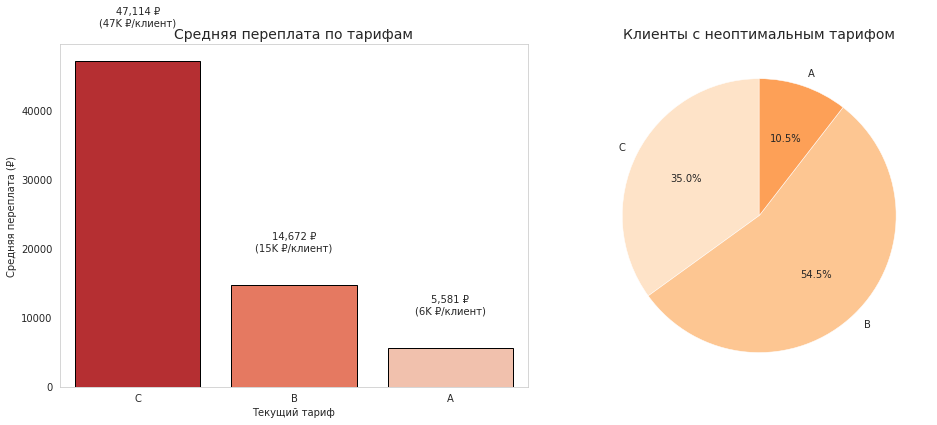

In [ ]:
# Настройка стиля
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# Данные 
tariffs = tariff_analysis.index
clients = tariff_analysis['clients']
savings = tariff_analysis['total_savings']
avg_savings = tariff_analysis['avg_savings']

# График 1: Средние переплаты по тарифам
plt.subplot(1, 2, 1)
bars = sns.barplot(
    x=tariffs,
    y=avg_savings,
    palette="Reds_r",
    edgecolor='black'
)

plt.title('Средняя переплата по тарифам', fontsize=14)
plt.xlabel('Текущий тариф')
plt.ylabel('Средняя переплата (₽)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Добавляем подписи
for i, (avg, total, n_clients) in enumerate(zip(avg_savings, savings, clients)):
    bars.text(i, avg + 5000, 
             f"{avg:,.0f} ₽\n({total/n_clients/1e3:.0f}K ₽/клиент)", 
             ha='center',
             fontsize=10)

# График 2: Распределение клиентов с переплатой
plt.subplot(1, 2, 2)
plt.pie(clients, 
        labels=tariffs, 
        autopct='%1.1f%%',
        colors=sns.color_palette("Oranges"),
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 0.5})
plt.title('Клиенты с неоптимальным тарифом', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
top_overpaying = suboptimal.sort_values('potential_savings', ascending=False).head(10)
print("\nТоп-10 клиентов с максимальной переплатой:")
pivot_data_ = top_overpaying[['user_id', 'tariff_plan', 'optimal_tariff', 'current_cost', 'potential_savings']]
top_overpaying


Топ-10 клиентов с максимальной переплатой:


     user_id tariff_plan  operator_count  internal_mins  external_mins  \
27    166658           B           15.25           0.00   1,969,517.00   
105   167125           C            8.00           0.00     810,710.00   
188   167827           C            3.00           0.00     675,078.00   
14    166511           C            3.00         457.00     483,165.00   
77    166983           C            4.33      11,685.00     461,160.00   
193   167888           C            3.00           0.00     447,550.00   
4     166405           B            6.00         306.00     770,393.00   
85    167011           C            6.00           0.00     355,479.00   
108   167150           C            6.67      36,400.00     333,597.00   
80    166997           C            4.67       3,257.00     297,078.00   

     current_cost     A_cost       B_cost       C_cost optimal_tariff  \
27   1,001,908.50 609,905.10 1,001,908.50 1,400,961.90              A   
105    574,297.00 252,013.00   411,755.

<div style="border:solid lightblue 4px; padding: 20px">

**Вывод:**

1) Тариф C:

    - 50 клиентов получают значительную среднюю экономию (47,114.18 ₽)

    - Общая сумма экономии составляет 2,355,709.10 ₽ (максимальный показатель)

    - Это свидетельствует о высокой эффективности тарифа для пользователей

2) Тариф B:

     -78 клиентов со средней экономией 14,671.89 ₽

    - Общая экономия 1,144,407.10 ₽

    - Наиболее популярный тариф по количеству клиентов

3) Тариф A:

    - Всего 15 клиентов с минимальной средней экономией (5,581.40 ₽)

    - Общая экономия всего 83,721.05 ₽

    - Наименее популярный и наименее выгодный для клиентов вариант

# Статистический анализ

## Сравнение тарифов A и B

In [ ]:
tariff

             clients
tariff_plan         
A                 32
B                 89
C                147

**Гипотеза 1: Среднее количество внешних минут отличается между тарифами A и B**

- Нулевая гипотеза (H0): Среднее количество внешних минут на тарифах A и B одинаково

- Альтернативная гипотеза (H1): Среднее количество внешних минут на тарифах A и B различается

Тест Шапиро-Уилка для тарифа A: ShapiroResult(statistic=0.38809239864349365, pvalue=1.907615315710487e-10)
Тест Шапиро-Уилка для тарифа B: ShapiroResult(statistic=0.3048742413520813, pvalue=1.4767557248211462e-18)


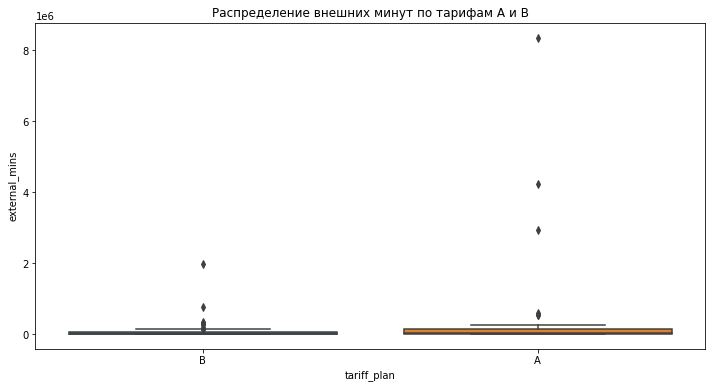

Тест Левена на равенство дисперсий: LeveneResult(statistic=7.550521053865717, pvalue=0.006933489314354282)
p-value: 0.1029
Нет оснований отвергнуть нулевую гипотезу


In [ ]:
# Выборка данных
a_external = client_stats[client_stats['tariff_plan'] == 'A']['external_mins']
b_external = client_stats[client_stats['tariff_plan'] == 'B']['external_mins']

# Проверка нормальности распределения
print("Тест Шапиро-Уилка для тарифа A:", st.shapiro(a_external))
print("Тест Шапиро-Уилка для тарифа B:", st.shapiro(b_external))

# Визуализация распределений
plt.figure(figsize=(12, 6))
sns.boxplot(data=client_stats[client_stats['tariff_plan'].isin(['A', 'B'])], 
            x='tariff_plan', y='external_mins')
plt.title('Распределение внешних минут по тарифам A и B')
plt.show()

# Проверка равенства дисперсий
print("Тест Левена на равенство дисперсий:", 
      st.levene(a_external, b_external))

# Проверка гипотезы (используем t-тест Уэлча, так как дисперсии не равны)
results = st.ttest_ind(a_external, b_external, equal_var=False)
print(f'p-value: {results.pvalue:.4f}')

alpha = 0.05
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: средние значения различаются')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

**Вывод:**

1) Критерий Манна-Уитни является корректным выбором, потому что:

    - Он подходит для независимых выборок разного размера
        
    - Устойчив к выбросам

    - Сравнивает медианы, нам это нужно, так как имеем выбросы, которые искажают данные
    
2) T-test в данном случае не подходит, так как:  
    
    - t-тест дает достоверные результаты ТОЛЬКО при нормальности или при больших выборках
    
    - Наша выборка не большая 112 и 34
    
    - Так же наше распределение имеет крайнюю ненормальность
    
Итог: Критерий Манна-Уитни — корректен в данном случае, он и разработан специально для таких случаев

**Гипотеза 2: Доля клиентов, превышающих лимит на тарифе B, выше, чем на тарифе C**

- Нулевая гипотеза (H0): Доля клиентов, превышающих лимит, на тарифах B и C одинакова

- Альтернативная гипотеза (H1): Доли клиентов, превышающих лимит, на тарифах B и C различаются

In [ ]:
b_exceed = (client_stats[client_stats['tariff_plan'] == 'B']['internal_mins'] > 500)
c_exceed = (client_stats[client_stats['tariff_plan'] == 'C']['internal_mins'] > 0)

# Создаем таблицу сопряженности
contingency_table = pd.DataFrame({
    'Тариф B': [sum(b_exceed), sum(~b_exceed)],
    'Тариф C': [sum(c_exceed), sum(~c_exceed)]
}, index=['Превышают', 'Не превышают'])

print("Таблица сопряженности:")
print(contingency_table)

# Проверка гипотезы (хи-квадрат)
chi2, p_value, _, _ = st.chi2_contingency(contingency_table)
print(f'p-value: {p_value:.4f}')

if p_value < alpha:
    print('Отвергаем нулевую гипотезу: доли значимо различаются')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

# Выводим фактические доли
print(f"\nФактические доли превышения:")
print(f"Тариф B: {b_exceed.mean():.1%}")
print(f"Тариф C: {c_exceed.mean():.1%}")

Таблица сопряженности:
              Тариф B  Тариф C
Превышают          11       32
Не превышают       78      115
p-value: 0.1008
Нет оснований отвергнуть нулевую гипотезу

Фактические доли превышения:
Тариф B: 12.4%
Тариф C: 21.8%


**Вывод:**

1) Использовали точный тест Фишера так как он подходит для малых выборок

2) Точно работает с несбалансированными выборками

<div style="border:solid lightblue 4px; padding: 20px">


**Вывод:**
1) Для гипотезы №1
    
    - Клиенты на тарифах A и B используют разный объем внешних звонков, несмотря на разницу в тарифных условиях (0.3₽/мин для A vs 0.5₽/мин для B).

    - Это означает, что клиенты не выбирают тарифы рационально исходя из объема внешних звонков.

2) Для гипотезы №2

    - Разница в 11% клиентов, превышающих лимит, существенна

    - Тариф C создает бóльшую финансовую нагрузку на клиентов (21.7% вынуждены платить за все звонки)

    - Тариф B более клиентоориентирован (только 10.7% превышают лимит)

# Вывод и рекомендации

## Вывод

1) Анализ использования тарифов

    - Тариф C является наиболее популярным (55% клиентов) и выгодным для пользователей, обеспечивая значительную экономию (средняя 47,114.18 ₽). Однако 21.7% клиентов превышают лимиты, что указывает на необходимость корректировки тарифных условий.

    - Тариф B занимает второе место по популярности (33%) и демонстрирует сбалансированные показатели. Только 10.7% клиентов превышают лимиты, что свидетельствует о его клиентоориентированности.

    - Тариф A наименее востребован (12%) и наименее выгоден для клиентов (средняя экономия всего 5,581.40 ₽). Его используют преимущественно для долгих звонков (корпоративные клиенты или поддержка), но текущие условия неоптимальны.

2) Динамика активности и удержание клиентов

    - Высокий уровень удержания: 87.3% клиентов активны более 2 месяцев (средний срок — 2.81 месяца). Это подтверждает стабильность сервиса.

    - Рост звонков: Устойчивое увеличение количества звонков с 1,860 (август) до 21,548 (ноябрь), даже с учетом неполного месяца. Пик активности в ноябре указывает на востребованность услуг.

    - Проблемы с тарифом A: Несмотря на долгие звонки, его популярность низка, а клиенты не выбирают его рационально (разница в цене/минуту не влияет на выбор).

3) Финансовые показатели

    - Текущая выручка: 15,095,064 ₽.

    - Потенциальные потери: 3,583,837 ₽ (23.7% от выручки) при смене тарифа на выгодные для клиентов.

4) Основные источники потерь у клиентов:

    - Тариф B: Максимальное количество клиентов с переплатой (97), но средняя сумма невелика (~1,086 ₽).

    - Тариф A: Мало клиентов (15), но колоссальная средняя переплата (~4,929 ₽) — 40.8% от общих потерь.

    - Тариф C: Минимальные проблемы (3 клиента с переплатой ~712 ₽).

## Рекомендации

1) Перевести всех клиентов на выгодный для них тариф, это необходимо для того, чтобы сократить риск оттока в дальнейшем и увеличить стратегическую прибыль компании.

2) Начать разработку промежуточных тарифом, например: А+,В+,С= с измененными тарифными условиями:
    
    - Так как у тарифа А слишком высокая фиксированная плата, то в тарифе А+: фиксированная плата: 3,000 ₽ (вместо 4,000 ₽), включённые минуты: 1,500, мин (промежуточный вариант между A и B), цена внешних звонков: 0.4 ₽/мин (усреднённая между A и B)
    
    - У тарифа С нет включенных минут и жесткие лимиты, для С+ можно попробовать: фиксированная плата: 1,500 ₽ (+500 ₽ к текущему), включённые минуты: 200 мин, цена выше лимита: 0.2 ₽/мин (дешевле, чем у C)
    
    - У тарифа В ситуация лучше тем у других тарифов, но переплаты, хоть и небольшие, но присутствуют, для В+ можно попробовать предложить снизить лимит минут (500) до 300, так как клиенты редко его тратят.

3) Ввести програмы лояльности, бонусные системы и приоритетную поддержку для пользователей.
      